# Random Forest Regression Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.tree import plot_tree

In [2]:
df = pd.read_csv('data/finalCards.csv')
df.head()

,uuid,cardName,availability,colorIdentity,defense,edhrecRank,edhrecSaltiness,finishes,isAlternative,isGameChanger,...,isRogue,isShaman,isDruid,isCreature,isPlaneswalker,isMTGO,isLegal,isBanned,isBattle,isFlying
0,00010d56-fe38-5e35-8aed-518019aa36a5,Sphinx of the Final Word,paper,U,NaN,10186.0,0.14,foil,False,False,...,False,False,False,True,False,False,True,False,False,True
1,0001e0d0-2dcd-5640-aadc-a84765cf5fc9,Goblin King,paper,R,NaN,3454.0,0.34,nonfoil,False,False,...,False,False,False,True,False,False,True,False,False,NaN
2,0003caab-9ff5-5d1a-bc06-976dd0457f19,Caravan Vigil,"mtgo, paper",G,NaN,12489.0,0.08,"nonfoil, foil",False,False,...,NaN,NaN,NaN,False,False,True,True,False,False,False
3,0003d249-25d9-5223-af1e-1130f09622a7,Deadshot Minotaur,"mtgo, paper","G, R",NaN,25150.0,0.20,"nonfoil, foil",False,False,...,False,False,False,True,False,True,True,False,False,False
4,0004822c-c181-5564-808d-a6cc48359a1a,Clone Legion,"arena, mtgo, paper",U,NaN,3488.0,0.48,"nonfoil, foil",False,False,...,NaN,NaN,NaN,False,False,True,True,False,False,NaN


In [3]:
df.columns

Index(['uuid', 'cardName', 'availability', 'colorIdentity', 'defense',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReprint', 'isReserved', 'keywords',
       'layout', 'loyalty', 'manaCost', 'manaValue', 'cardNumber', 'power',
       'rarity', 'setCode', 'subtypes', 'supertypes', 'text', 'toughness',
       'types', 'variations', 'price', 'commander', 'setName', 'releaseDate',
       'scryfallId', 'tcgplayerProductId', 'multiverseId', 'isHuman',
       'isElemental', 'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire',
       'isZombie', 'isBeast', 'isEldrazi', 'isWizard', 'isSoldier', 'isKnight',
       'isCleric', 'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isCreature',
       'isPlaneswalker', 'isMTGO', 'isLegal', 'isBanned', 'isBattle',
       'isFlying'],
      dtype='object')

## 1. Feature Selection/Refining of Data

In [4]:
df.isnull().sum()

uuid                      0
cardName                  0
availability              0
colorIdentity             0
defense               94070
edhrecRank             5583
edhrecSaltiness       12559
finishes                  0
isAlternative             0
isGameChanger             0
isPromo                   0
isReprint                 0
isReserved                0
keywords                  0
layout                    0
loyalty               92819
manaCost              12343
manaValue                 0
cardNumber                0
power                 49461
rarity                    0
setCode                   0
subtypes                  0
supertypes                0
text                    975
toughness             49309
types                     0
variations            61719
price                     0
commander                 0
setName                   0
releaseDate               0
scryfallId                0
tcgplayerProductId     1083
multiverseId          27020
isHuman             

In [5]:
# convert boolean columns (True/False) to int (1/0)
bool_cols = ['isAlternative', 'isGameChanger', 'isPromo', 'isReprint',
            'isReserved', 'isHuman', 'isElemental', 'isDragon', 
            'isSpirit', 'isAngel', 'isElf', 'isVampire',
            'isZombie', 'isBeast', 'isEldrazi', 'isWizard', 
            'isSoldier', 'isKnight','isCleric', 'isWarrior', 
            'isRogue', 'isShaman', 'isDruid', 'isCreature',
            'isPlaneswalker', 'isMTGO', 'isLegal', 'isBanned', 
            'isBattle', 'isFlying']
df[bool_cols] = df[bool_cols].fillna(0).astype(int)

In [6]:
df['colorIdentity'] = df['colorIdentity'].str.split(', ')

In [7]:
# one-hot encode color identity and rarity
mlb = MultiLabelBinarizer()
encoded_colors = mlb.fit_transform(df['colorIdentity'])
colors_df = pd.DataFrame(encoded_colors, columns='c_'+mlb.classes_, index=df.index)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_rarity = ohe.fit_transform(df[['rarity']])
rarity_df = pd.DataFrame(encoded_rarity, columns=ohe.get_feature_names_out(['rarity']), index=df.index)

features = pd.concat([colors_df, rarity_df], axis=1)
features.head()

,c_B,c_Colorless,c_G,c_R,c_U,c_W,rarity_common,rarity_mythic,rarity_rare,rarity_special,rarity_uncommon
0,0,0,0,0,1,0,0.0,1.0,0.0,0.0,0.0
1,0,0,0,1,0,0,0.0,0.0,1.0,0.0,0.0
2,0,0,1,0,0,0,1.0,0.0,0.0,0.0,0.0
3,0,0,1,1,0,0,1.0,0.0,0.0,0.0,0.0
4,0,0,0,0,1,0,0.0,1.0,0.0,0.0,0.0


In [8]:
df = df.join(features)
df.drop(columns=['colorIdentity', 'rarity'], axis=1, inplace=True)
df.columns

Index(['uuid', 'cardName', 'availability', 'defense', 'edhrecRank',
       'edhrecSaltiness', 'finishes', 'isAlternative', 'isGameChanger',
       'isPromo', 'isReprint', 'isReserved', 'keywords', 'layout', 'loyalty',
       'manaCost', 'manaValue', 'cardNumber', 'power', 'setCode', 'subtypes',
       'supertypes', 'text', 'toughness', 'types', 'variations', 'price',
       'commander', 'setName', 'releaseDate', 'scryfallId',
       'tcgplayerProductId', 'multiverseId', 'isHuman', 'isElemental',
       'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire', 'isZombie',
       'isBeast', 'isEldrazi', 'isWizard', 'isSoldier', 'isKnight', 'isCleric',
       'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isCreature',
       'isPlaneswalker', 'isMTGO', 'isLegal', 'isBanned', 'isBattle',
       'isFlying', 'c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'c_W',
       'rarity_common', 'rarity_mythic', 'rarity_rare', 'rarity_special',
       'rarity_uncommon'],
      dtype='object')

### Setup Creature Features

In [9]:
creature_df = df[(df['isCreature'] == 1)].copy().reset_index()
creature_df = creature_df[['edhrecRank', 'edhrecSaltiness', 'isAlternative', 'isGameChanger',
                            'isPromo', 'isReprint', 'isReserved', 'isHuman', 'isElemental',
                            'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire', 'isZombie',
                            'isBeast', 'isEldrazi', 'isWizard', 'isSoldier', 'isKnight','isCleric',
                            'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isMTGO', 'isLegal',
                            'isBanned', 'isFlying', 'manaValue', 'power', 'supertypes', 'toughness',
                            'price', 'c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'c_W',
                            'rarity_common', 'rarity_mythic', 'rarity_rare', 'rarity_special',
                            'rarity_uncommon', 'text']]

len(creature_df)

44836

In [10]:
creature_df['isLegendary'] = creature_df['supertypes'].str.contains('Legendary').astype(int)
creature_df.drop('supertypes', axis=1, inplace=True)

creature_df['isLegendary'].value_counts()

isLegendary
0    34571
1    10265
Name: count, dtype: int64

In [11]:
# add interaction terms based on unsupervised model cluster map
creature_df['isBlackFlying'] = creature_df['c_B'] & creature_df['isFlying']
creature_df['isGreenHumanWarrior'] = creature_df['c_G'] & creature_df['isHuman'] & creature_df['isWarrior']
creature_df['isWhiteHumanCleric'] = creature_df['c_W'] & creature_df['isHuman'] & creature_df['isCleric']

print(creature_df['isBlackFlying'].value_counts())
print(creature_df['isGreenHumanWarrior'].value_counts())
print(creature_df['isWhiteHumanCleric'].value_counts())

isBlackFlying
0    42534
1     2302
Name: count, dtype: int64
isGreenHumanWarrior
0    44497
1      339
Name: count, dtype: int64
isWhiteHumanCleric
0    44165
1      671
Name: count, dtype: int64


In [12]:
def priceOutlier(df):
    df['Zscore'] = zscore(df['price'])

    no_outliers = df[df['Zscore'].abs() <= 3]
    no_outliers = no_outliers.drop(columns=['Zscore'])
    print(len(df), len(no_outliers))

    return no_outliers

In [13]:
creature_df['price'].sort_values(ascending=False)

7031     20840.000000
23614     4827.996667
42093     3599.990000
3672      3515.540000
6635      3362.183333
             ...     
395          0.090000
43710        0.082000
13820        0.030000
21763        0.030000
42520        0.020000
Name: price, Length: 44836, dtype: float64

In [14]:
creature_df = priceOutlier(creature_df)
creature_df['price'].sort_values(ascending=False)

44836 44698


19984    369.745000
24626    369.440000
44190    364.281667
40412    360.890000
32675    350.714000
            ...    
395        0.090000
43710      0.082000
13820      0.030000
21763      0.030000
42520      0.020000
Name: price, Length: 44698, dtype: float64

In [15]:
def addTextFeatures(df, words):
    for word in words:
        df['t_'+word] = df['text'].str.contains(word).fillna(0).astype(int)
    return df

In [16]:
# add the following words as features based on ridge with tfidf model 
creature_words = ["enters", "whenever", "spell", "flying", "end"]
creature_df = addTextFeatures(creature_df, creature_words)
creature_df.drop('text', axis=1, inplace=True)    

In [17]:
creature_df.columns

Index(['edhrecRank', 'edhrecSaltiness', 'isAlternative', 'isGameChanger',
       'isPromo', 'isReprint', 'isReserved', 'isHuman', 'isElemental',
       'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire', 'isZombie',
       'isBeast', 'isEldrazi', 'isWizard', 'isSoldier', 'isKnight', 'isCleric',
       'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isMTGO', 'isLegal',
       'isBanned', 'isFlying', 'manaValue', 'power', 'toughness', 'price',
       'c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'c_W', 'rarity_common',
       'rarity_mythic', 'rarity_rare', 'rarity_special', 'rarity_uncommon',
       'isLegendary', 'isBlackFlying', 'isGreenHumanWarrior',
       'isWhiteHumanCleric', 't_enters', 't_whenever', 't_spell', 't_flying',
       't_end'],
      dtype='object')

### Setup Planeswalker Features

In [18]:
planeswalker_df = df[(df['isPlaneswalker'] == 1)].copy().reset_index()
planeswalker_df = planeswalker_df[['edhrecRank', 'edhrecSaltiness', 'isAlternative', 'isGameChanger',
                                'isPromo', 'isReprint', 'isReserved', 'manaValue', 'price',
                                'c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'c_W',
                                'rarity_common', 'rarity_mythic', 'rarity_rare', 'rarity_special',
                                'rarity_uncommon', 'text']]
len(planeswalker_df)

1324

In [19]:
planeswalker_df = priceOutlier(planeswalker_df)
planeswalker_df['price'].sort_values(ascending=False)

1324 1308


237     155.6700
860     152.2560
772     134.0500
917     132.1475
236      92.3250
          ...   
1199      0.1975
363       0.1820
353       0.1820
817       0.1780
1246      0.1600
Name: price, Length: 1308, dtype: float64

In [20]:
# add the following words as features based on ridge with tfidf model 
planeswalker_words = ["creature"]
planeswalker_df = addTextFeatures(planeswalker_df, planeswalker_words)
planeswalker_df.drop('text', axis=1, inplace=True)   

In [21]:
planeswalker_df.columns

Index(['edhrecRank', 'edhrecSaltiness', 'isAlternative', 'isGameChanger',
       'isPromo', 'isReprint', 'isReserved', 'manaValue', 'price', 'c_B',
       'c_Colorless', 'c_G', 'c_R', 'c_U', 'c_W', 'rarity_common',
       'rarity_mythic', 'rarity_rare', 'rarity_special', 'rarity_uncommon',
       't_creature'],
      dtype='object')

### Setup Non-Creature Features

In [22]:
noncreature_df = df[(df['isCreature'] == 0)].copy().reset_index()
noncreature_df = noncreature_df[['edhrecRank', 'edhrecSaltiness', 'isAlternative', 'isGameChanger',
                                'isPromo', 'isReprint', 'isReserved', 'manaValue', 'price',
                                'c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'c_W',
                                'rarity_common', 'rarity_mythic', 'rarity_rare', 'rarity_special',
                                'rarity_uncommon', 'isPlaneswalker', 'isBattle', 'isFlying', 'isEldrazi', 'text']]
len(noncreature_df)

49287

In [23]:
noncreature_df = priceOutlier(noncreature_df)
noncreature_df['price'].sort_values(ascending=False)

49287 49190


31115    1540.355000
37594    1540.294000
26963    1522.516667
31576    1500.228000
462      1499.990000
            ...     
38759       0.095000
21900       0.090000
38275       0.030000
26612       0.030000
6847        0.020000
Name: price, Length: 49190, dtype: float64

In [24]:
# add the following words as features based on lasso with tfidf model 
noncreature_words = ["enters", "card", "target", "enchant creature", "enchant", "creature"]
noncreature_df = addTextFeatures(noncreature_df, noncreature_words)
noncreature_df.drop('text', axis=1, inplace=True)   

In [25]:
noncreature_df.columns

Index(['edhrecRank', 'edhrecSaltiness', 'isAlternative', 'isGameChanger',
       'isPromo', 'isReprint', 'isReserved', 'manaValue', 'price', 'c_B',
       'c_Colorless', 'c_G', 'c_R', 'c_U', 'c_W', 'rarity_common',
       'rarity_mythic', 'rarity_rare', 'rarity_special', 'rarity_uncommon',
       'isPlaneswalker', 'isBattle', 'isFlying', 'isEldrazi', 't_enters',
       't_card', 't_target', 't_enchant creature', 't_enchant', 't_creature'],
      dtype='object')

## 2. Train the Model using Grid Search

In [26]:
def randForestGridSearch(df):
    y = df['price']
    X = df.drop(columns=['price'], axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    param_grid = {
        'n_estimators': [100, 500],
        'max_depth': [10, 15],
        'max_features': ['sqrt', None],
        'min_samples_leaf': [3, 5]
    }

    rf = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')
    grid_search.fit(X_train, y_train)

    print(f"Best parameters found: {grid_search.best_params_}")
    print("-----------------")

    model = grid_search.best_estimator_
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'Mean Absolute Error: {mae:.2f}')
    print(f'Mean Squared Error: {mse:.2f}')
    print(f'R-squared: {r2:.2f}')

    return model

### Creature Model

In [27]:
creature_model = randForestGridSearch(creature_df)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 500}
-----------------
Mean Absolute Error: 4.63
Mean Squared Error: 347.86
R-squared: 0.21


### Planeswalker Model

In [28]:
planeswalker_model = randForestGridSearch(planeswalker_df)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 500}
-----------------
Mean Absolute Error: 6.32
Mean Squared Error: 141.33
R-squared: 0.13


### Non-Creature Model

In [29]:
noncreature_model = randForestGridSearch(noncreature_df)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 500}
-----------------
Mean Absolute Error: 9.50
Mean Squared Error: 2696.10
R-squared: 0.29


## 3. Visualize Feature Importance

In [30]:
def visFeatureImportance(df, model, model_name):
    X = df.drop(columns=['price'], axis=1)

    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances.sort_values().plot(kind='barh', figsize=(10, 6), color='r')
    plt.title(f"Feature Importance of {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    # return top features that add up to 0.9 importance score
    top_importances = importances.sort_values(ascending=False)
    cumsum = top_importances.cumsum()
    return top_importances[cumsum <= 0.9].index.tolist()

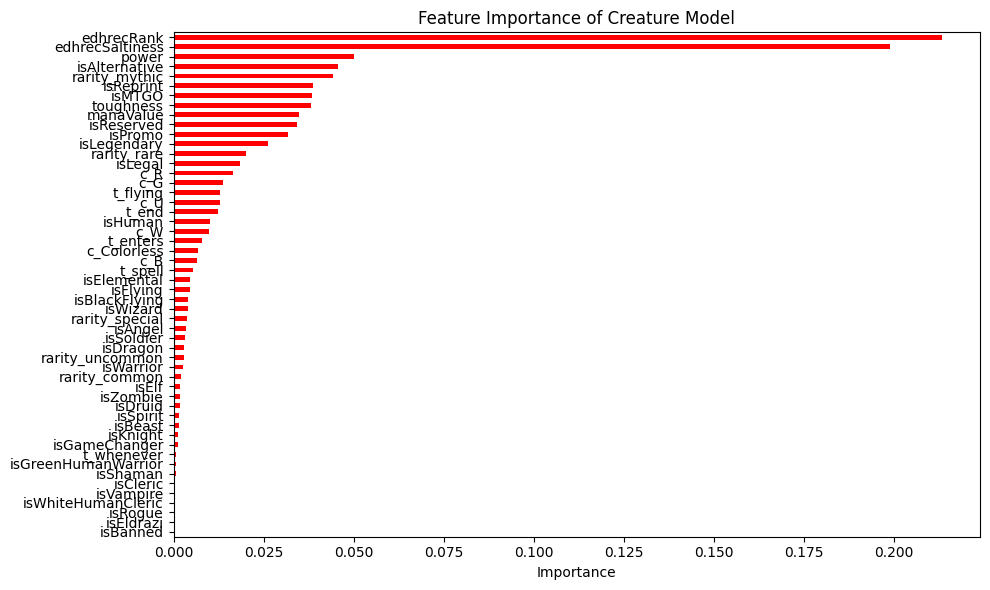

In [31]:
creature_top_features = visFeatureImportance(creature_df, creature_model, "Creature Model")

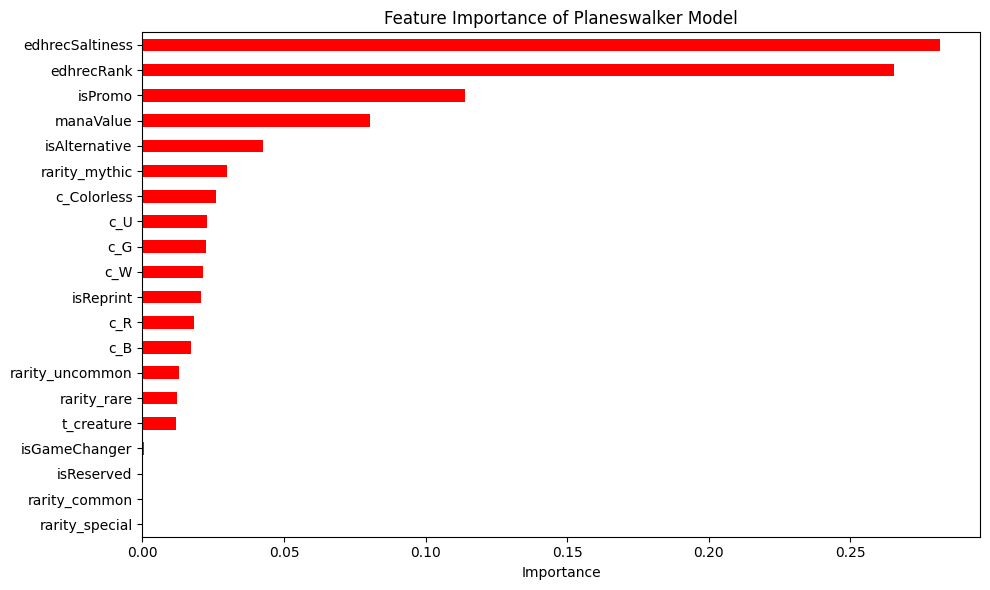

In [32]:
planeswalker_top_features = visFeatureImportance(planeswalker_df, planeswalker_model, "Planeswalker Model")

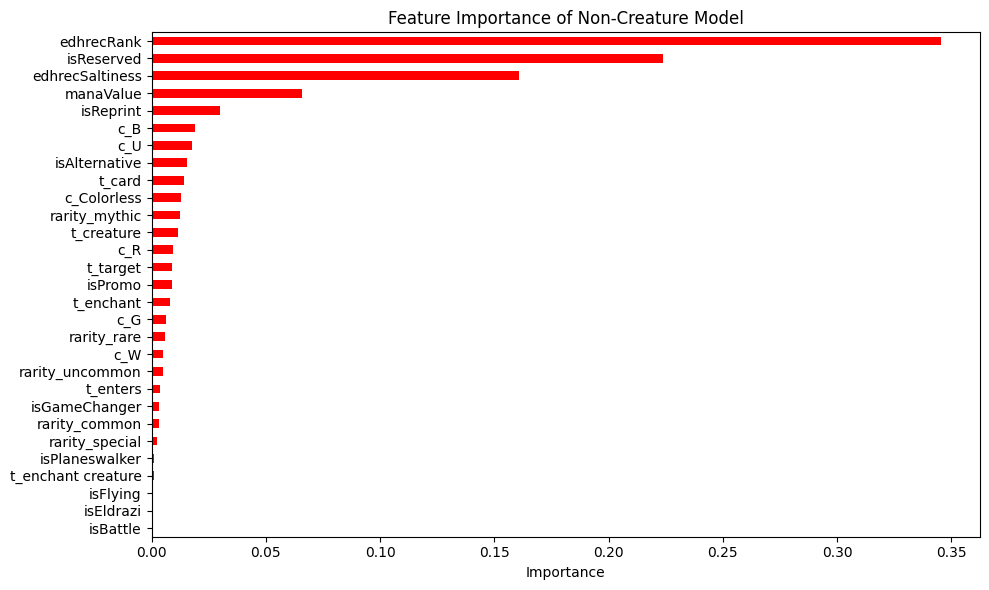

In [33]:
noncreature_top_features = visFeatureImportance(noncreature_df, noncreature_model, "Non-Creature Model")

### Plot single decision tree (creature model)

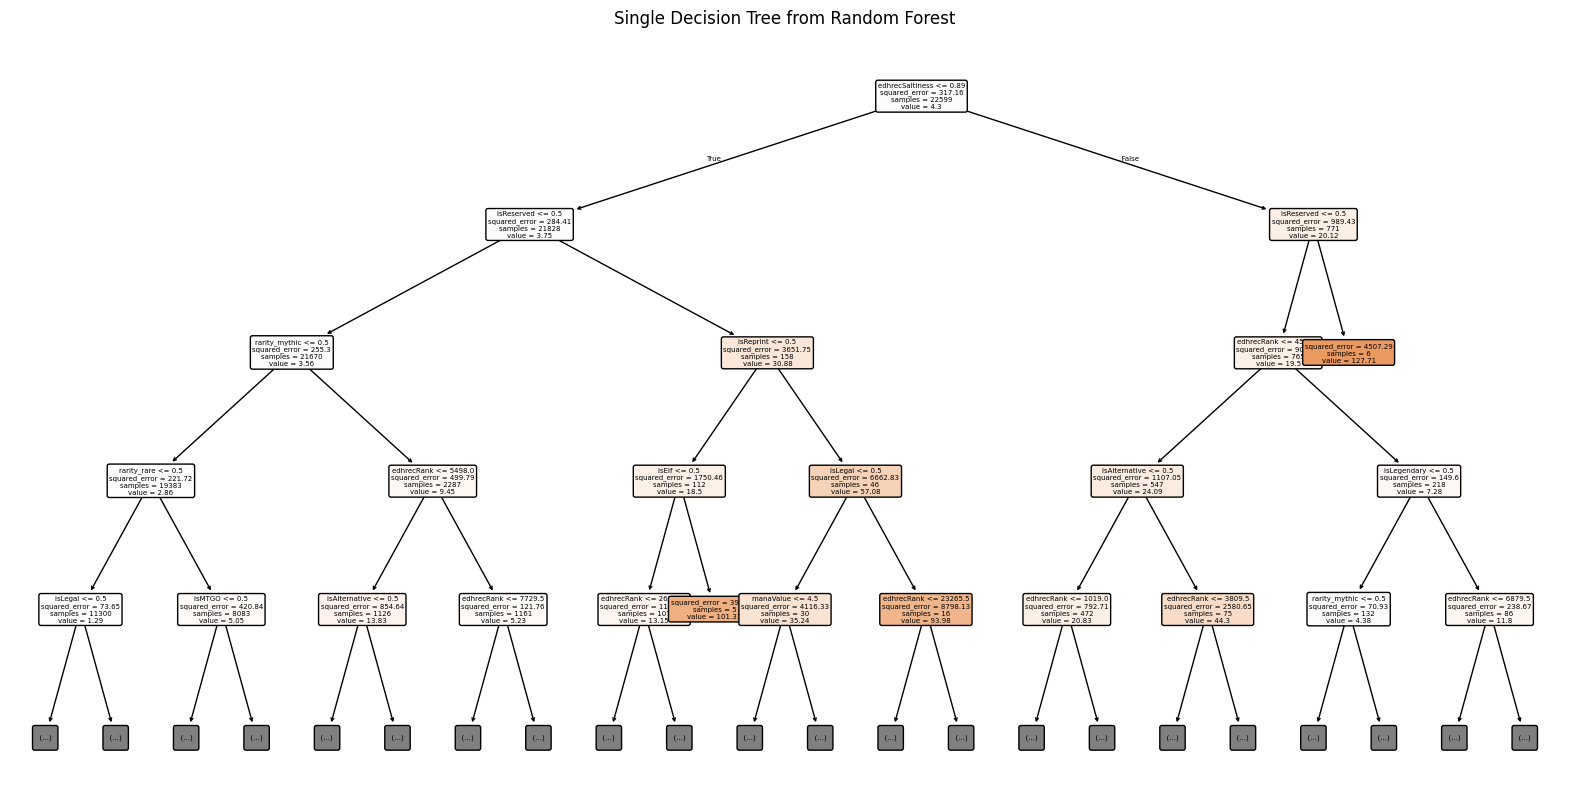

In [34]:
estimator = creature_model.estimators_[0]
X = creature_df.drop(columns=['price'], axis=1)

plt.figure(figsize=(20, 10))
plot_tree(estimator, 
          feature_names=X.columns,
          filled=True, 
          rounded=True,
          precision=2,
          proportion=False,
          fontsize=5,
          max_depth=4)
plt.title("Single Decision Tree from Random Forest")
plt.show()

## 4. Retrain the Model using Top Features

In [35]:
subset_creature_df = creature_df[['price'] + creature_top_features]
randForestGridSearch(subset_creature_df)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 100}
-----------------
Mean Absolute Error: 4.68
Mean Squared Error: 347.18
R-squared: 0.21


RandomForestRegressor(max_depth=15, max_features=None, min_samples_leaf=5,
                      random_state=42)

In [36]:
subset_planeswalker_df = planeswalker_df[['price'] + planeswalker_top_features]
randForestGridSearch(subset_planeswalker_df)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 500}
-----------------
Mean Absolute Error: 6.34
Mean Squared Error: 143.73
R-squared: 0.12


RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=3,
                      n_estimators=500, random_state=42)

In [37]:
subset_noncreature_df = noncreature_df[['price'] + noncreature_top_features]
randForestGridSearch(subset_noncreature_df)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500}
-----------------
Mean Absolute Error: 10.02
Mean Squared Error: 2657.02
R-squared: 0.30


RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=5,
                      n_estimators=500, random_state=42)